# 入门

In [29]:
import torch
from mpmath import zeros

x=torch.arange(12)
print(x)
x.shape

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])


torch.Size([12])

In [30]:
y=x.reshape(3,4)
y

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [31]:
x=torch.ones(3,4)
y=torch.zeros(3,4)
x

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [32]:
y

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [33]:
torch.randn(3,4)

tensor([[ 0.1781,  0.2463, -0.3964,  0.6357],
        [ 0.1893,  0.5201,  0.5636,  2.5012],
        [ 0.2255, -0.4526,  0.0440, -0.4599]])

In [34]:
ls=torch.cat((x,y),dim=0)# dim 0 时 竖着连接，1时横着连接
ls

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [35]:
a=torch.arange(3).reshape((1,3))
b=torch.arange(3).reshape((3,1)) #复制行和列相加
print(a)
print(b)
print(a+b)
c=a+b
print(id(c))
c[0,0]=10
print(c)
c[1:2,0:2]=10
print(c)

tensor([[0, 1, 2]])
tensor([[0],
        [1],
        [2]])
tensor([[0, 1, 2],
        [1, 2, 3],
        [2, 3, 4]])
1641434719440
tensor([[10,  1,  2],
        [ 1,  2,  3],
        [ 2,  3,  4]])
tensor([[10,  1,  2],
        [10, 10,  3],
        [ 2,  3,  4]])


In [36]:
c[:]=torch.arange(9).reshape((3,3))#这样可以在原来的c的内存上面操作，可以节省内存
print(id(c))
c=torch.arange(9).reshape((3,3))
print(id(c))#这样就会重新分配新的内存
c+=c # 这样内存也不会变
print(id(c))
c*c

1641434719440
1641498242528
1641498242528


tensor([[  0,   4,  16],
        [ 36,  64, 100],
        [144, 196, 256]])

In [37]:
print(c)
c_sum=c.sum(axis=0)

tensor([[ 0,  2,  4],
        [ 6,  8, 10],
        [12, 14, 16]])


In [38]:
c_sum

tensor([18, 24, 30])

In [39]:
print(c.cumsum(axis=0))

tensor([[ 0,  2,  4],
        [ 6, 10, 14],
        [18, 24, 30]])


In [24]:
u=torch.tensor([3.0,-4.0])# L2 范数 x 平方和的二次方
torch.norm(u)

tensor(5.)

In [25]:
torch.abs(u).sum() #L1 范数

tensor(7.)

In [26]:
x=torch.arange(4.0,requires_grad=True)

In [27]:
y=2*torch.dot(x,x)
y

tensor(28., grad_fn=<MulBackward0>)

In [28]:
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

In [29]:
x.grad==4*x

tensor([True, True, True, True])

In [30]:
x.grad.zero_()
y=x.sum()
y.backward()
x.grad


tensor([1., 1., 1., 1.])

In [31]:
#当y不是标量时 累加在反向传播
x.grad.zero_()
y=x*x
y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

In [32]:
#分离计算
x.grad.zero_()
y=x*x
u=y.detach()#把y当做常数
z=u*x
z.sum().backward()
x.grad

tensor([0., 1., 4., 9.])

In [33]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l
# 获取随机的数据对
def synthetic_data(w,b,num_examples):
    x=torch.normal(0,1,(num_examples,len(w)))
    y= torch.matmul(x,w)+b
    y+= torch.normal(0,0.01,y.shape)
    return x,y.reshape((-1,1))


In [34]:
true_w=torch.tensor([2,-3.4])
true_b=4.2
features, labels=synthetic_data(true_w,true_b,1000)

In [35]:
print('features',features[0],'\nlabels',labels[0])

features tensor([ 0.1347, -0.3248]) 
labels tensor([5.5675])


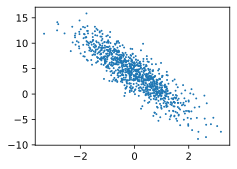

In [36]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [37]:
# 分批次读取数据
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [38]:
batch_size= 10
for x, y in data_iter(batch_size, features, labels):
    print(x,"\n",y)
    break

tensor([[ 0.7027,  0.6055],
        [ 1.4375,  0.9089],
        [ 0.1914, -0.1494],
        [ 0.2018, -1.2256],
        [-0.9071,  0.6514],
        [-2.0715,  1.5721],
        [-0.1769,  0.8504],
        [ 1.1539, -1.1018],
        [-0.2755,  0.7786],
        [-0.1986, -0.1510]]) 
 tensor([[ 3.5452],
        [ 3.9928],
        [ 5.1056],
        [ 8.7707],
        [ 0.1689],
        [-5.2779],
        [ 0.9603],
        [10.2515],
        [ 0.9872],
        [ 4.3368]])


In [39]:
#初始化模型参数
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [40]:
def linreg(x,w,b): #模型
    return torch.matmul(x,w)+b
def squared_loss(y_hat,y): # 损失函数
    return (y_hat-y.reshape(y_hat.shape))**2/2
def sgd(params, lr, batch_size):  #优化器
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [41]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

In [42]:
for epoch in range(num_epochs):
    for x, y in data_iter(batch_size, features, labels):
        l = loss(net(x,w,b), y)
        l.sum().backward()
        sgd([w,b], lr, batch_size)
        with torch.no_grad():
            train_l= loss(net(features,w,b), labels)
            print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 15.862023
epoch 1, loss 15.434878
epoch 1, loss 14.625678
epoch 1, loss 13.457757
epoch 1, loss 12.693915
epoch 1, loss 12.222190
epoch 1, loss 11.500506
epoch 1, loss 10.718848
epoch 1, loss 10.046416
epoch 1, loss 9.555937
epoch 1, loss 8.847000
epoch 1, loss 7.973807
epoch 1, loss 7.302269
epoch 1, loss 6.988391
epoch 1, loss 6.837268
epoch 1, loss 6.449223
epoch 1, loss 6.230999
epoch 1, loss 5.576059
epoch 1, loss 5.443739
epoch 1, loss 5.193298
epoch 1, loss 5.034179
epoch 1, loss 4.747741
epoch 1, loss 4.361442
epoch 1, loss 4.160969
epoch 1, loss 3.990340
epoch 1, loss 3.811722
epoch 1, loss 3.547590
epoch 1, loss 3.466105
epoch 1, loss 3.323581
epoch 1, loss 3.049185
epoch 1, loss 2.933167
epoch 1, loss 2.800767
epoch 1, loss 2.593902
epoch 1, loss 2.429096
epoch 1, loss 2.212811
epoch 1, loss 2.132601
epoch 1, loss 1.996011
epoch 1, loss 1.844664
epoch 1, loss 1.779229
epoch 1, loss 1.670093
epoch 1, loss 1.554610
epoch 1, loss 1.431744
epoch 1, loss 1.354767
ep

In [43]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

In [44]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

In [45]:
def load_array(data_arrays, batch_size, is_train=True):
    dataset = data.TensorDataset(*data_arrays)# 解包语法，如传入多个数据组 可以解包，此函数用于缝合数据组,访问 dataset[0] 时，它会同时返回 (features[0], labels[0])。
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

In [46]:
batch_size = 10
data_iter = load_array((features,labels), batch_size, True)
next(iter(data_iter))

[tensor([[-2.0254, -0.0833],
         [-1.0054,  0.1970],
         [-0.1497, -0.1916],
         [-0.3576,  1.6869],
         [ 0.1773,  2.2604],
         [-0.1974,  0.4007],
         [ 0.9980, -0.9544],
         [-0.6612,  1.2237],
         [-0.2928,  1.0499],
         [ 1.6722,  0.7115]]),
 tensor([[ 0.4577],
         [ 1.5148],
         [ 4.5574],
         [-2.2647],
         [-3.1168],
         [ 2.4484],
         [ 9.4392],
         [-1.2741],
         [ 0.0493],
         [ 5.1197]])]

In [47]:
# 模型
from torch import nn
net= nn.Sequential(nn.Linear(2,1))
net[0].weight.data.normal_(0.0, 0.01)
net[0].bias.data.fill_(0)


tensor([0.])

In [48]:
loss=nn.MSELoss()

In [49]:
trainer= torch.optim.SGD(net.parameters(), lr=0.03)

In [50]:
num_epochs = 3
for epoch in range(num_epochs):
    for x, y in data_iter:
        l=loss(net(x),y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l=loss(net(features),labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000246
epoch 2, loss 0.000100
epoch 3, loss 0.000101


## softmax回归

In [51]:
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

In [52]:
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

In [53]:
def get_fashion_mnist_labels(labels):
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat','sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

In [54]:
def show_images(imgs,num_rows,num_cols,titles=None,scale=1.5):
    figsize=(num_cols*num_rows, num_rows*scale)
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
        # 图片张量
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)
            ax.axes.get_xaxis().set_visible(False)
            ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

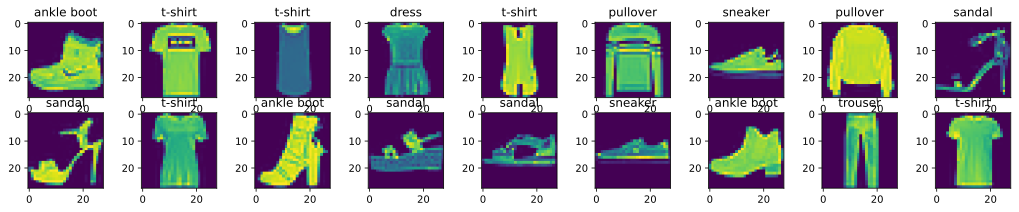

In [55]:
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y));

In [56]:
batch_size= 256
def get_dataloader_workers():
    return 4
train_iter = data.DataLoader(mnist_train, batch_size,shuffle=True,num_workers=get_dataloader_workers())

In [57]:
timer= d2l.Timer()
for x, y in train_iter:
    continue
print(f"{timer.stop():.2f} second")

6.38 second


In [58]:
def load_data_fashion_mnist(batch_size, resize=None): #@save
    """下载Fashion-MNIST数据集，然后将其加载到内存中"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))

In [59]:
train_iter,test_iter = load_data_fashion_mnist(32,resize=64)
for x,y in train_iter:
    print(x.shape, x.dtype,y.shape, y.dtype)
    break

torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64


In [60]:
import torch
from IPython import display

In [61]:
batch_size= 256
train_iter , test_iter= d2l.load_data_fashion_mnist(batch_size)

In [62]:
num_inputs=784
num_outputs=10
W= torch.normal(0,0.01,size=(num_inputs,num_outputs),requires_grad=True)
b= torch.zeros(num_outputs,requires_grad=True)

In [63]:
def softmax(x):
    x_exp = torch.exp(x)
    partition= x_exp.sum(1,keepdim=True)
    return x_exp/partition

In [64]:
X = torch.normal(0, 1, (2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.2611, 0.4090, 0.2369, 0.0704, 0.0226],
         [0.0729, 0.1943, 0.4831, 0.1107, 0.1391]]),
 tensor([1.0000, 1.0000]))

In [65]:
def net(x):
    return softmax(torch.matmul(x.reshape(-1,W.shape[0]),W)+b)

In [66]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y])

In [67]:
def accuracy(y_hat, y): #@save
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

In [68]:
class Accumulator: #@save
    def __init__(self, n):
        self.data = [0.0] * n
    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]
    def reset(self):
        self.data = [0.0] * len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

In [69]:
def evaluate_accuracy(net,data_iter):
    if isinstance(net, torch.nn.Module):
        net.eval()
    metric=Accumulator(2)
    with torch.no_grad():
        for x,y in data_iter:
            metric.add(accuracy(net(x),y),y.numel())
    return metric[0]/metric[1]

In [13]:
import IPython.display as display
def fake_clear_output(wait=False):
    pass
def train_epoch_ch3(net,train_iter,loss,updater):#@save
    if isinstance(net, torch.nn.Module):
        net.train()
    metric = Accumulator(3)
    for x,y in train_iter:
        y_hat=net(x)
        l=loss(y_hat,y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            l.sum().backward()
            updater(x.shape[0])
        metric.add(float(l.sum()),accuracy(y_hat,y),y.numel())
        display.clear_output = fake_clear_output
    return metric[0]/metric[2],metric[1]/metric[2]


In [12]:
class Animator: #@save
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,ylim=None, xscale='linear', yscale='linear',fmts=('-', 'm--', 'g-.', 'r:'), nrows=1,ncols=1,figsize=(3.5, 2.5)):
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [106]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater): #@save
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

In [89]:
lr = 0.1
def updater(batch_size):
    return d2l.sgd([W, b], lr, batch_size)

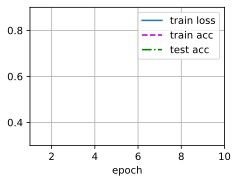

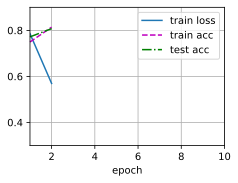

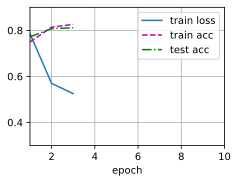

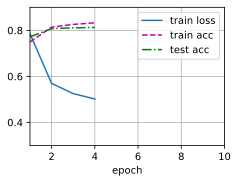

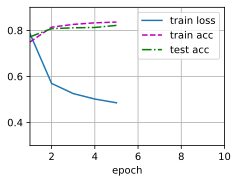

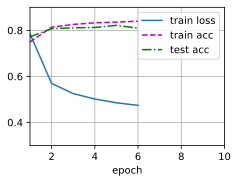

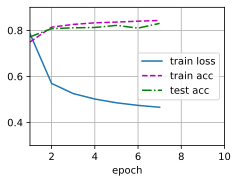

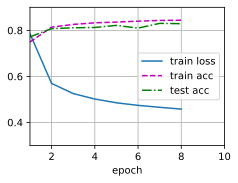

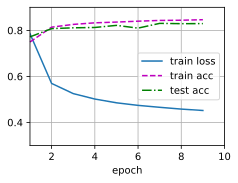

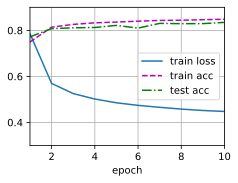

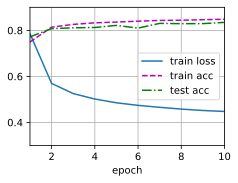

In [90]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

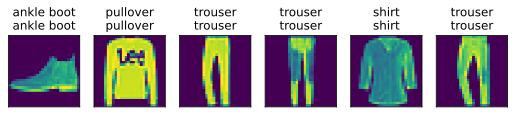

In [91]:
def predict_ch3(net, test_iter, n=6):
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])
predict_ch3(net, test_iter)

In [92]:
# softmax 回归的简洁实现\
from torch import nn
from d2l import torch as d2l
batch_size =256
train_iter, test_iter= d2l.load_data_fashion_mnist(batch_size)
net= nn.Sequential(nn.Flatten(),nn.Linear(784, 10))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight,std=0.01)
net.apply(init_weights);

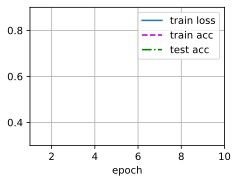

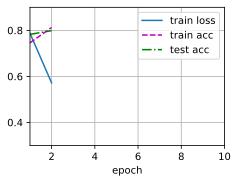

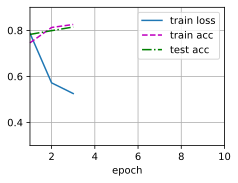

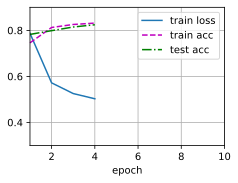

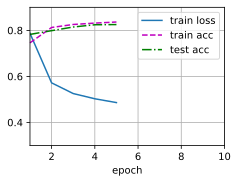

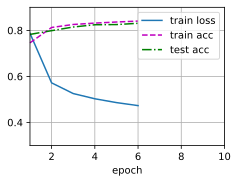

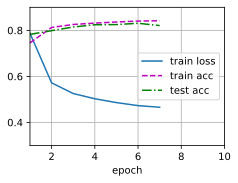

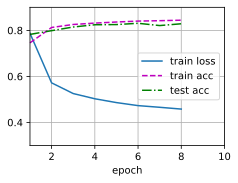

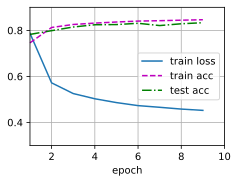

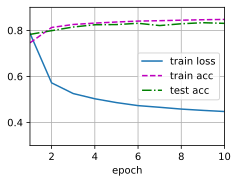

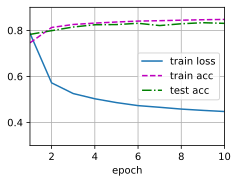

In [93]:
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.1)
num_epochs = 10
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

# 多层感知机

In [94]:
%matplotlib inline
import torch
from d2l import torch as d2l

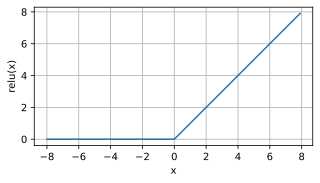

In [95]:
#激活函数
# relu 函数
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)
d2l.plot(x.detach(), y.detach(), 'x', 'relu(x)', figsize=(5, 2.5))

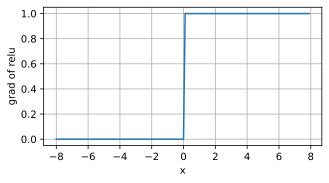

In [96]:
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of relu', figsize=(5, 2.5))

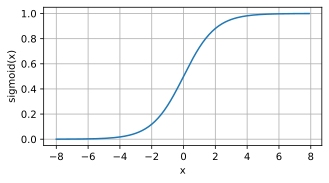

In [97]:
# sigmoid 函数
y = torch.sigmoid(x)
d2l.plot(x.detach(), y.detach(), 'x', 'sigmoid(x)', figsize=(5, 2.5))

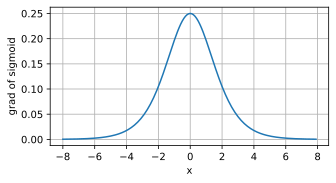

In [98]:
x.grad.data.zero_()
y.backward(torch.ones_like(x),retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of sigmoid', figsize=(5, 2.5))

In [99]:
#多层感知机的实现
import torch
from torch import nn
from d2l import torch as d2l
batch_size= 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
num_inputs,num_outputs,num_hiddens = 784,10,256

W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2]
def relu(X):
    a= torch.zeros_like(X)
    return torch.max(X,a)
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X @ W1 + b1)
    return (H @ W2 + b2)
loss = nn.CrossEntropyLoss(reduction='none')

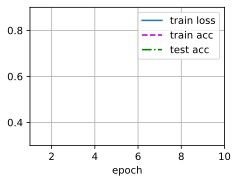

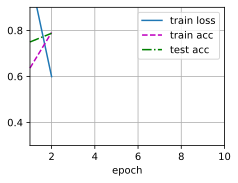

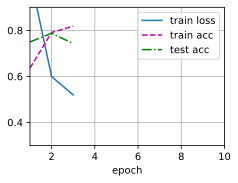

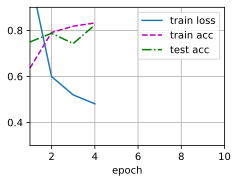

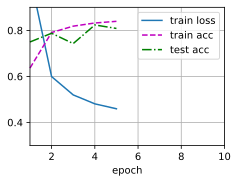

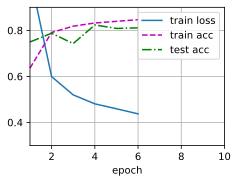

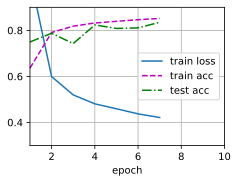

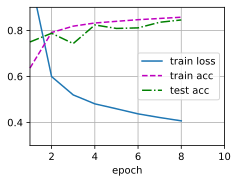

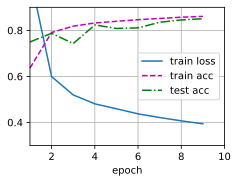

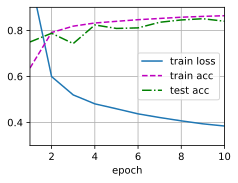

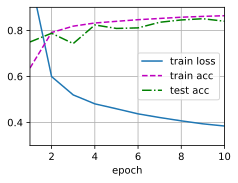

In [100]:
num_epochs , lr= 10, 0.1
updater = torch.optim.SGD(params, lr=lr)
train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)

In [101]:
import torch
from torch import nn
from d2l import torch as d2l

In [102]:
net= nn.Sequential(nn.Flatten(),nn.Linear(784, 256),nn.ReLU(),nn.Linear(256,10))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight,std=0.01)

net.apply(init_weights);

In [103]:
batch_size, lr, num_epochs = 256, 0.1, 10
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

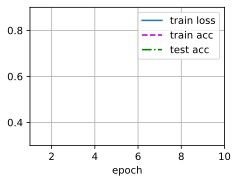

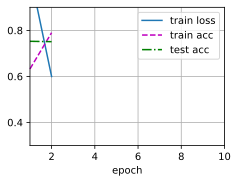

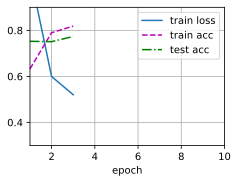

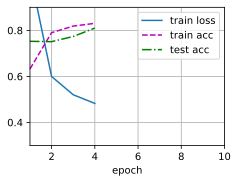

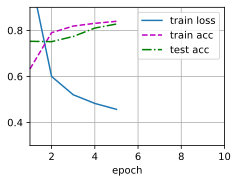

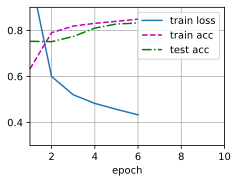

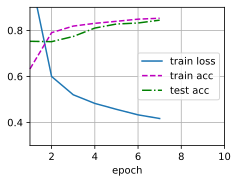

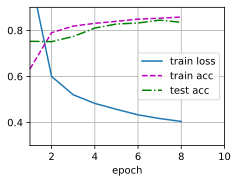

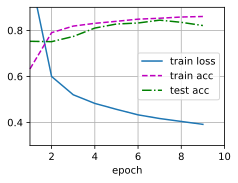

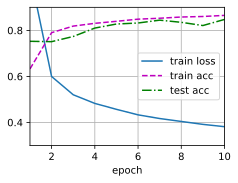

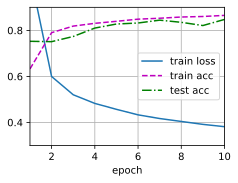

In [104]:
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

In [105]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

In [106]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

In [107]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

In [108]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

In [109]:
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了L2范数惩罚项，
            # 广播机制使l2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),d2l.evaluate_loss(net, test_iter, loss)))
        print('w的L2范数是：', torch.norm(w).item())

w的L2范数是： 13.958562850952148
w的L2范数是： 13.803560256958008
w的L2范数是： 13.68353271484375
w的L2范数是： 13.590508460998535


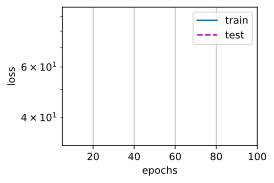

w的L2范数是： 13.518393516540527
w的L2范数是： 13.462227821350098
w的L2范数是： 13.418560028076172
w的L2范数是： 13.3841552734375
w的L2范数是： 13.357076644897461


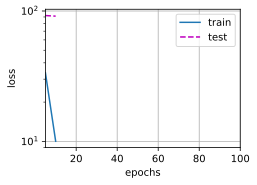

w的L2范数是： 13.335600852966309
w的L2范数是： 13.318450927734375
w的L2范数是： 13.304807662963867
w的L2范数是： 13.293854713439941
w的L2范数是： 13.285018920898438


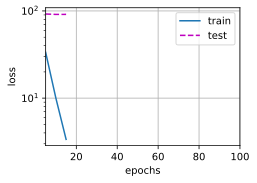

w的L2范数是： 13.27786922454834
w的L2范数是： 13.272058486938477
w的L2范数是： 13.267294883728027
w的L2范数是： 13.263400077819824
w的L2范数是： 13.260196685791016


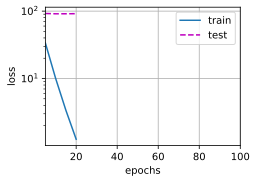

w的L2范数是： 13.257554054260254
w的L2范数是： 13.255362510681152
w的L2范数是： 13.253545761108398
w的L2范数是： 13.252028465270996
w的L2范数是： 13.250761985778809


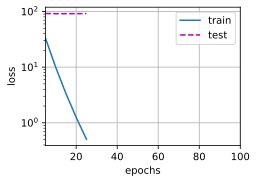

w的L2范数是： 13.249704360961914
w的L2范数是： 13.248810768127441
w的L2范数是： 13.248064994812012
w的L2范数是： 13.247434616088867
w的L2范数是： 13.246901512145996


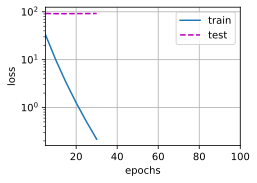

w的L2范数是： 13.246452331542969
w的L2范数是： 13.246068954467773
w的L2范数是： 13.245743751525879
w的L2范数是： 13.245468139648438
w的L2范数是： 13.245231628417969


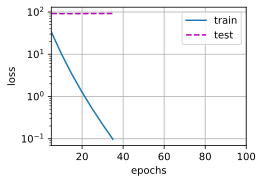

w的L2范数是： 13.245030403137207
w的L2范数是： 13.244857788085938
w的L2范数是： 13.244710922241211
w的L2范数是： 13.244584083557129
w的L2范数是： 13.244475364685059


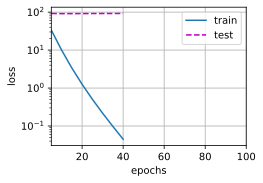

w的L2范数是： 13.244382858276367
w的L2范数是： 13.244301795959473
w的L2范数是： 13.244232177734375
w的L2范数是： 13.244174003601074
w的L2范数是： 13.244122505187988


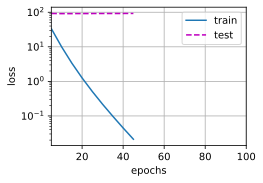

w的L2范数是： 13.244078636169434
w的L2范数是： 13.244040489196777
w的L2范数是： 13.24400806427002
w的L2范数是： 13.243978500366211
w的L2范数是： 13.243953704833984


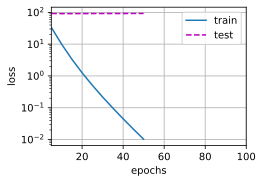

w的L2范数是： 13.24393367767334
w的L2范数是： 13.243914604187012
w的L2范数是： 13.24389934539795
w的L2范数是： 13.243884086608887
w的L2范数是： 13.24387264251709


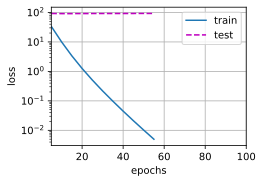

w的L2范数是： 13.24386215209961
w的L2范数是： 13.243852615356445
w的L2范数是： 13.243844032287598
w的L2范数是： 13.243837356567383
w的L2范数是： 13.243830680847168


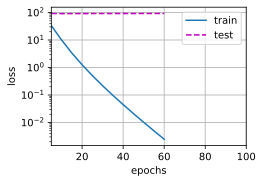

w的L2范数是： 13.24382495880127
w的L2范数是： 13.243821144104004
w的L2范数是： 13.243816375732422
w的L2范数是： 13.243813514709473
w的L2范数是： 13.243810653686523


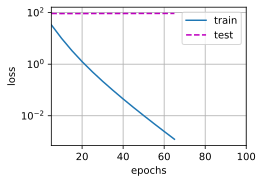

w的L2范数是： 13.243807792663574
w的L2范数是： 13.243805885314941
w的L2范数是： 13.243803024291992
w的L2范数是： 13.243802070617676
w的L2范数是： 13.243800163269043


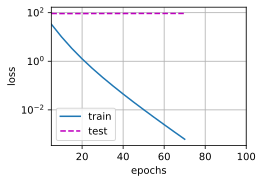

w的L2范数是： 13.24379825592041
w的L2范数是： 13.243797302246094
w的L2范数是： 13.243796348571777
w的L2范数是： 13.243794441223145
w的L2范数是： 13.243794441223145


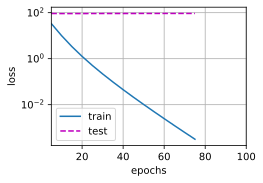

w的L2范数是： 13.243793487548828
w的L2范数是： 13.243793487548828
w的L2范数是： 13.243792533874512
w的L2范数是： 13.243791580200195
w的L2范数是： 13.243791580200195


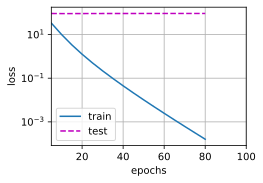

w的L2范数是： 13.243791580200195
w的L2范数是： 13.243790626525879
w的L2范数是： 13.243790626525879
w的L2范数是： 13.243790626525879
w的L2范数是： 13.243789672851562


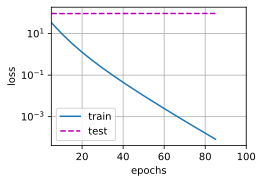

w的L2范数是： 13.243789672851562
w的L2范数是： 13.243789672851562
w的L2范数是： 13.243788719177246
w的L2范数是： 13.243788719177246
w的L2范数是： 13.243788719177246


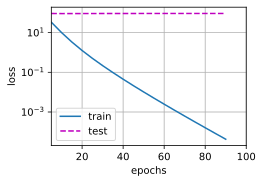

w的L2范数是： 13.243789672851562
w的L2范数是： 13.243788719177246
w的L2范数是： 13.243788719177246
w的L2范数是： 13.243788719177246
w的L2范数是： 13.243788719177246


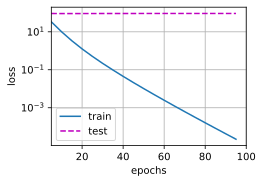

w的L2范数是： 13.243788719177246
w的L2范数是： 13.243788719177246
w的L2范数是： 13.243788719177246
w的L2范数是： 13.243788719177246
w的L2范数是： 13.243788719177246


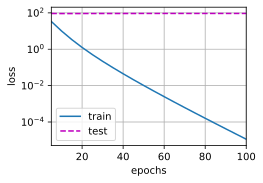

w的L2范数是： 13.243788719177246


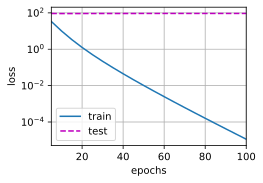

In [110]:
train(lambd=0)

w的L2范数是： 12.677639961242676
w的L2范数是： 12.126145362854004
w的L2范数是： 11.618701934814453
w的L2范数是： 11.147212028503418


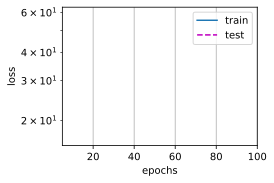

w的L2范数是： 10.706307411193848
w的L2范数是： 10.29116439819336
w的L2范数是： 9.898712158203125
w的L2范数是： 9.526178359985352
w的L2范数是： 9.171404838562012


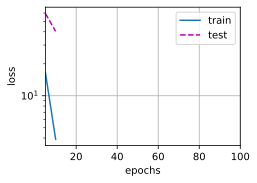

w的L2范数是： 8.832782745361328
w的L2范数是： 8.50890064239502
w的L2范数是： 8.19859790802002
w的L2范数是： 7.900949478149414
w的L2范数是： 7.615172863006592


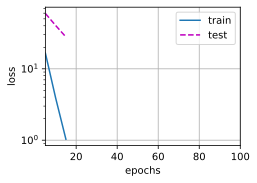

w的L2范数是： 7.340583324432373
w的L2范数是： 7.07653284072876
w的L2范数是： 6.822512149810791
w的L2范数是： 6.578024864196777
w的L2范数是： 6.342630386352539


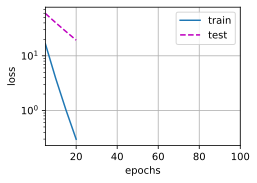

w的L2范数是： 6.115950107574463
w的L2范数是： 5.897576808929443
w的L2范数是： 5.687180519104004
w的L2范数是： 5.484428405761719
w的L2范数是： 5.289021015167236


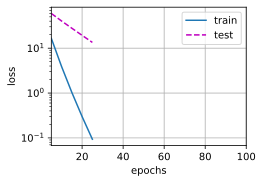

w的L2范数是： 5.100674152374268
w的L2范数是： 4.919111251831055
w的L2范数是： 4.744079113006592
w的L2范数是： 4.575329780578613
w的L2范数是： 4.412628173828125


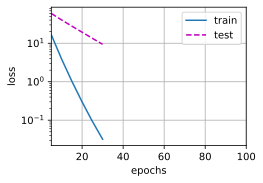

w的L2范数是： 4.255749225616455
w的L2范数是： 4.1044840812683105
w的L2范数是： 3.958624839782715
w的L2范数是： 3.817972421646118
w的L2范数是： 3.6823394298553467


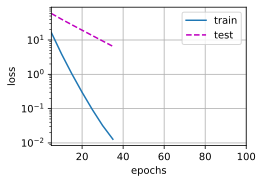

w的L2范数是： 3.551543951034546
w的L2范数是： 3.4254112243652344
w的L2范数是： 3.3037729263305664
w的L2范数是： 3.186466932296753
w的L2范数是： 3.073338270187378


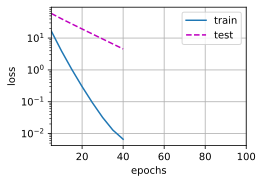

w的L2范数是： 2.9642374515533447
w的L2范数是： 2.859020709991455
w的L2范数是： 2.757549524307251
w的L2范数是： 2.659689426422119
w的L2范数是： 2.5653128623962402


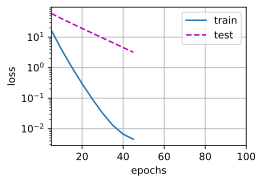

w的L2范数是： 2.474294900894165
w的L2范数是： 2.3865139484405518
w的L2范数是： 2.3018574714660645
w的L2范数是： 2.220214366912842
w的L2范数是： 2.1414754390716553


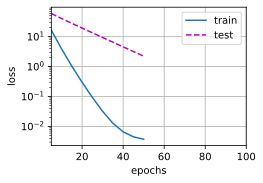

w的L2范数是： 2.065539836883545
w的L2范数是： 1.992303729057312
w的L2范数是： 1.921674132347107
w的L2范数是： 1.8535584211349487
w的L2范数是： 1.7878680229187012


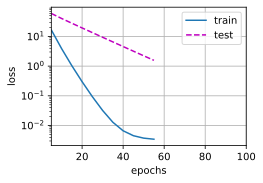

w的L2范数是： 1.7245174646377563
w的L2范数是： 1.6634191274642944
w的L2范数是： 1.6044973134994507
w的L2范数是： 1.5476734638214111
w的L2范数是： 1.4928736686706543


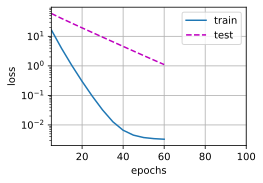

w的L2范数是： 1.4400241374969482
w的L2范数是： 1.389058232307434
w的L2范数是： 1.3399101495742798
w的L2范数是： 1.2925140857696533
w的L2范数是： 1.246806263923645


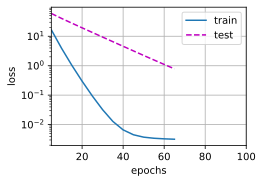

w的L2范数是： 1.2027225494384766
w的L2范数是： 1.1602152585983276
w的L2范数是： 1.1192271709442139
w的L2范数是： 1.0797028541564941
w的L2范数是： 1.041587233543396


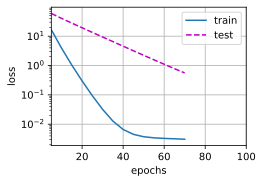

w的L2范数是： 1.0048335790634155
w的L2范数是： 0.9693900346755981
w的L2范数是： 0.9352144002914429
w的L2范数是： 0.9022646546363831
w的L2范数是： 0.8704888224601746


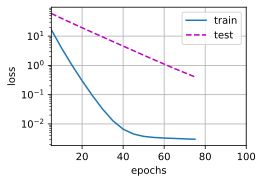

w的L2范数是： 0.8398522138595581
w的L2范数是： 0.8103102445602417
w的L2范数是： 0.7818261981010437
w的L2范数是： 0.7543612122535706
w的L2范数是： 0.7278837561607361


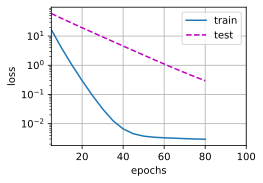

w的L2范数是： 0.7023559212684631
w的L2范数是： 0.677746057510376
w的L2范数是： 0.6540238261222839
w的L2范数是： 0.6311516165733337
w的L2范数是： 0.6091043949127197


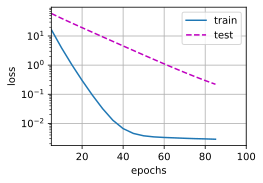

w的L2范数是： 0.5878487229347229
w的L2范数是： 0.5673608779907227
w的L2范数是： 0.5476146936416626
w的L2范数是： 0.5285847187042236
w的L2范数是： 0.5102408528327942


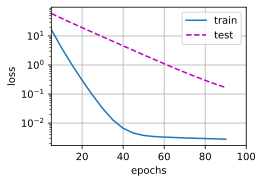

w的L2范数是： 0.4925636649131775
w的L2范数是： 0.475521981716156
w的L2范数是： 0.4591067135334015
w的L2范数是： 0.4432833790779114
w的L2范数是： 0.42803800106048584


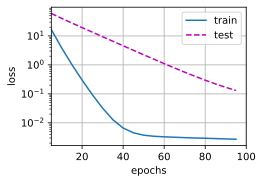

w的L2范数是： 0.413347452878952
w的L2范数是： 0.3992038071155548
w的L2范数是： 0.38557642698287964
w的L2范数是： 0.3724375069141388
w的L2范数是： 0.3597881495952606


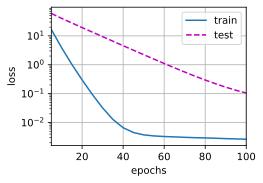

w的L2范数是： 0.347608745098114


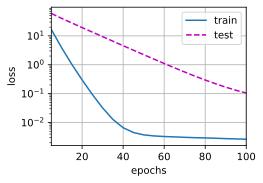

In [111]:
train(lambd=3)

In [112]:
# 高级api实现
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay': wd},
        {"params":net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                (d2l.evaluate_loss(net, train_iter, loss),
                d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数：', net[0].weight.norm().item())


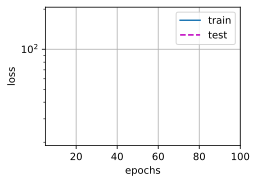

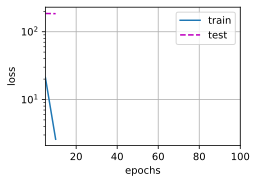

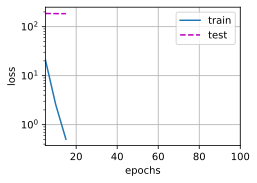

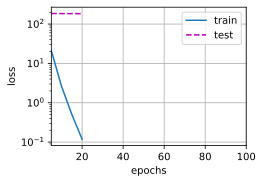

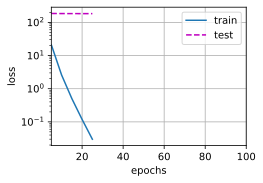

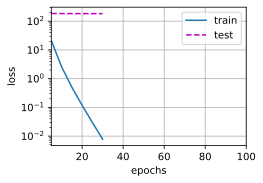

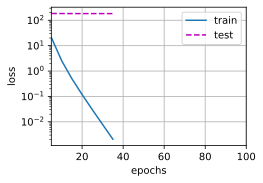

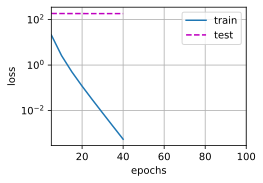

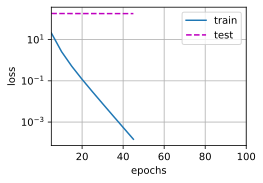

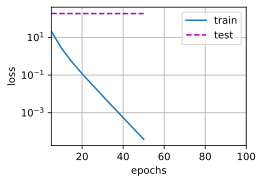

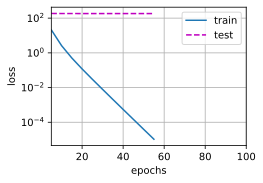

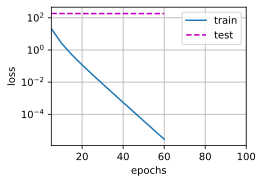

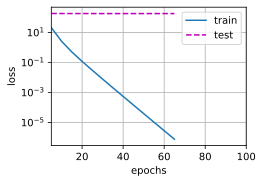

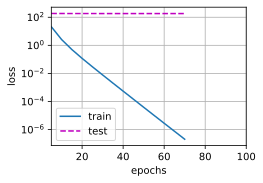

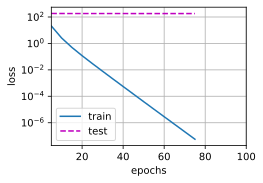

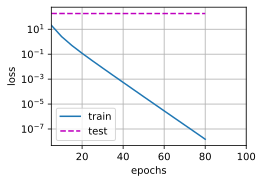

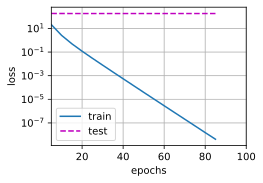

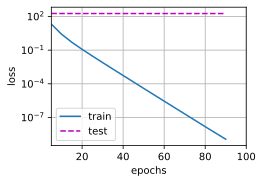

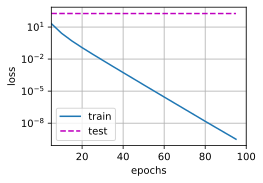

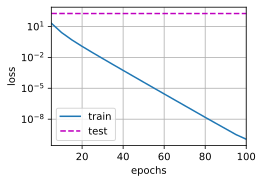

w的L2范数： 13.74232292175293


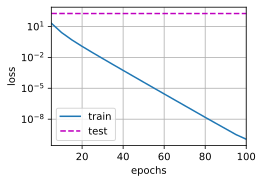

In [113]:
train_concise(0)

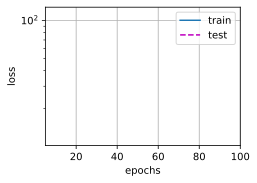

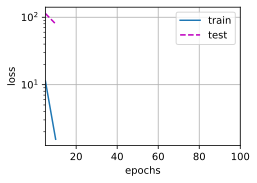

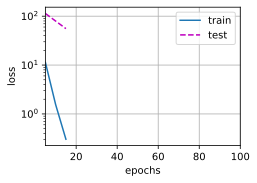

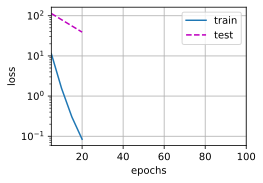

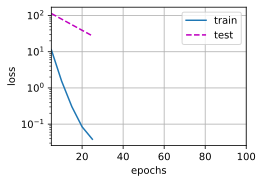

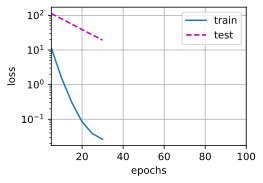

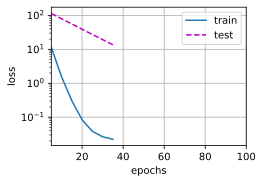

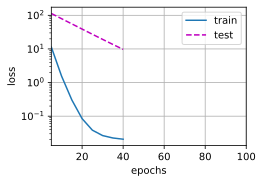

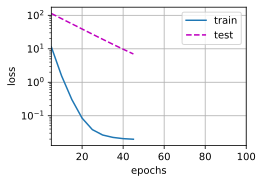

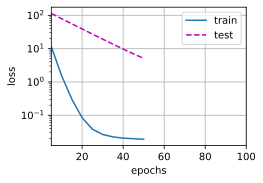

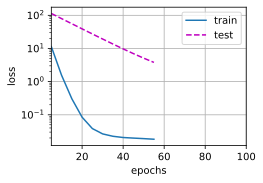

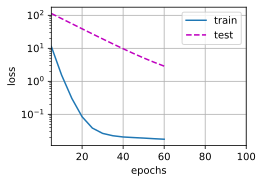

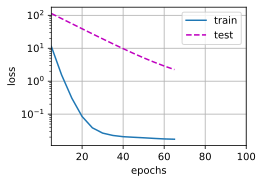

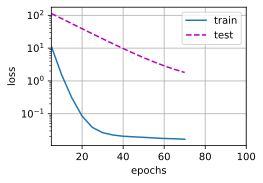

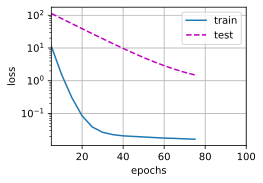

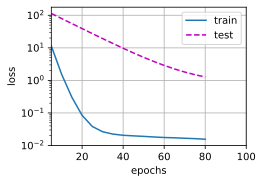

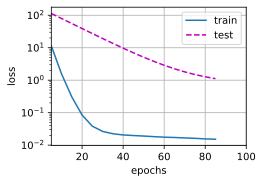

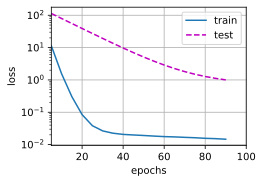

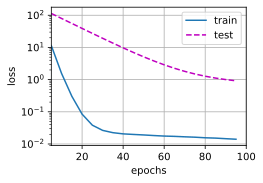

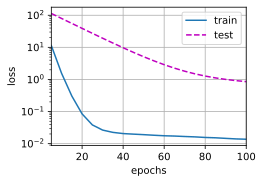

w的L2范数： 0.4474264681339264


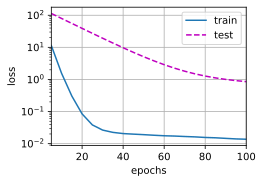

In [114]:
train_concise(3)

In [115]:
#暂退法
import torch
from torch import nn
from d2l import torch as d2l
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    # 在本情况中，所有元素都被丢弃
    if dropout == 1:
        return torch.zeros_like(X)
    # 在本情况中，所有元素都被保留
    if dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

In [116]:
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256

In [117]:
dropout1, dropout2 = 0.2, 0.5
class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,is_training = True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()
    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))# 只有在训练模型时才使用dropout
        if self.training == True:
        # 在第一个全连接层之后添加一个dropout层
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            # 在第二个全连接层之后添加一个dropout层
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out

In [118]:
net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

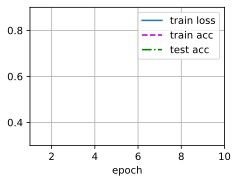

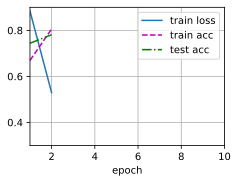

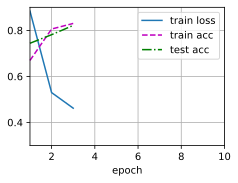

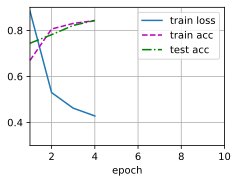

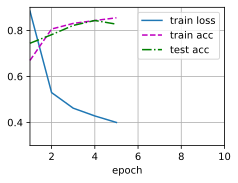

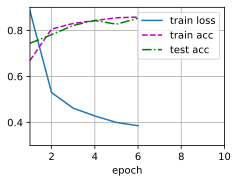

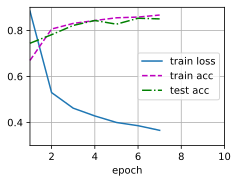

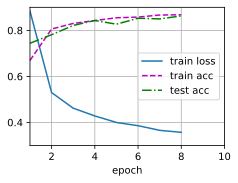

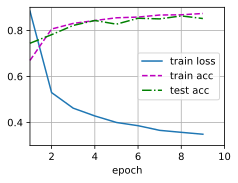

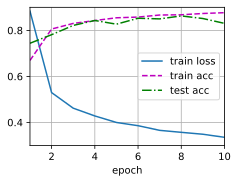

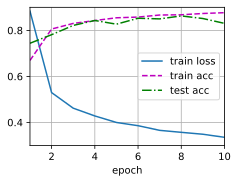

In [119]:
num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

In [121]:
net = nn.Sequential(nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    # 在第一个全连接层之后添加一个dropout层
    nn.Dropout(dropout1),
    nn.Linear(256, 256),
    nn.ReLU(),
    # 在第二个全连接层之后添加一个dropout层
    nn.Dropout(dropout2),
    nn.Linear(256, 10))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
net.apply(init_weights);

In [122]:
import hashlib
import os
import tarfile
import zipfile
import requests
#@save
DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

# 深度学习计算

In [88]:
import torch
from torch import nn
from torch.nn import functional as F
import numpy
class MLP(nn.Module):
    # 用模型参数声明层。这里，我们声明两个全连接的层
    def __init__(self):
    # 调用MLP的父类Module的构造函数来执行必要的初始化。
    # 这样，在类实例化时也可以指定其他函数参数，例如模型参数params（稍后将介绍）
        super().__init__()
        self.hidden = nn.Linear(20, 256) # 隐藏层
        self.out = nn.Linear(256, 10) # 输出层
    # 定义模型的前向传播，即如何根据输入X返回所需的模型输出
    def forward(self, X):
    # 注意，这里我们使用ReLU的函数版本，其在nn.functional模块中定义。
        return self.out(F.relu(self.hidden(X)))

In [89]:
net=MLP()
X = torch.rand(2, 20)
print(net(X))

tensor([[ 1.2811e-01, -9.6798e-02, -1.6407e-01, -3.4254e-02,  4.8399e-02,
          7.0252e-02, -1.6325e-01, -5.8188e-02, -6.1205e-02,  1.4091e-02],
        [ 5.4582e-02,  2.2678e-04, -2.3461e-01, -1.5452e-01, -7.0376e-02,
          5.5595e-02, -1.5489e-01,  8.3261e-03,  4.4820e-03,  7.3056e-03]],
       grad_fn=<AddmmBackward0>)


In [90]:
class MySequential(nn.Module):
    def __init__(self, *args):
        super().__init__()
        for idx, module in enumerate(args):
# 这里，module是Module子类的一个实例。我们把它保存在'Module'类的成员
# 变量_modules中。_module的类型是OrderedDict
            self._modules[str(idx)] = module
    def forward(self, X):
        # OrderedDict保证了按照成员添加的顺序遍历它们
        for block in self._modules.values():
            X = block(X)
        return X

In [91]:
net= MySequential(nn.Linear(20,256),nn.ReLU(),nn.Linear(256,10))
print(net(X))

tensor([[ 0.0663,  0.0645,  0.0484,  0.2545,  0.0873,  0.0318,  0.0715,  0.0314,
         -0.0053,  0.1510],
        [ 0.1661,  0.0329,  0.0467,  0.3388,  0.0701,  0.0985,  0.1879,  0.0981,
         -0.1097,  0.0420]], grad_fn=<AddmmBackward0>)


In [92]:
class FixedHiddenMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # 不计算梯度的随机权重参数。因此其在训练期间保持不变
        self.rand_weight = torch.rand((20, 20), requires_grad=False)
        self.linear = nn.Linear(20, 20)
    def forward(self, X):
        X = self.linear(X)
        # 使用创建的常量参数以及relu和mm函数
        X = F.relu(torch.mm(X, self.rand_weight) + 1)# 复用全连接层。这相当于两个全连接层共享参数
        X = self.linear(X)
        # 控制流
        while X.abs().sum() > 1:
            X /= 2
        return X.sum()

In [93]:
import torch
from torch import nn
net = nn.Sequential(nn.Linear(4, 8), nn.ReLU(), nn.Linear(8, 1))
X = torch.rand(size=(2, 4))
print(net(X))

tensor([[0.4398],
        [0.4755]], grad_fn=<AddmmBackward0>)


In [94]:
print(net[0].state_dict())

OrderedDict([('weight', tensor([[ 0.2650, -0.2926, -0.4610,  0.2231],
        [-0.3172, -0.3058, -0.1237, -0.1604],
        [ 0.4703,  0.4661,  0.2877,  0.2495],
        [-0.0418,  0.2234,  0.0200,  0.0110],
        [-0.3138,  0.0145,  0.0338,  0.3597],
        [-0.4925,  0.2583, -0.2871, -0.3828],
        [ 0.4475,  0.2814, -0.2329, -0.0955],
        [ 0.2471, -0.3590,  0.0413,  0.2030]])), ('bias', tensor([ 0.3581, -0.1824, -0.3705, -0.3261, -0.0605, -0.2142, -0.0515,  0.4990]))])


In [95]:
print(*[(name,param.shape) for name, param in net.named_parameters()])


('0.weight', torch.Size([8, 4])) ('0.bias', torch.Size([8])) ('2.weight', torch.Size([1, 8])) ('2.bias', torch.Size([1]))


In [96]:
print(net.state_dict()['0.bias'].data)

tensor([ 0.3581, -0.1824, -0.3705, -0.3261, -0.0605, -0.2142, -0.0515,  0.4990])


In [97]:
def block1():
    return nn.Sequential(nn.Linear(4,8),nn.ReLU(), nn.Linear(8,1), nn.ReLU())
def block2():
    net=nn.Sequential()
    for i in range(4):
        net.add_module(f'block{i}',block1())
    return net
rgnet=nn.Sequential(block2(),nn.Linear(4,1))
print(rgnet)

Sequential(
  (0): Sequential(
    (block0): Sequential(
      (0): Linear(in_features=4, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=1, bias=True)
      (3): ReLU()
    )
    (block1): Sequential(
      (0): Linear(in_features=4, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=1, bias=True)
      (3): ReLU()
    )
    (block2): Sequential(
      (0): Linear(in_features=4, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=1, bias=True)
      (3): ReLU()
    )
    (block3): Sequential(
      (0): Linear(in_features=4, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=1, bias=True)
      (3): ReLU()
    )
  )
  (1): Linear(in_features=4, out_features=1, bias=True)
)


In [98]:
def init_normal(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight,mean=0,std=0.01)
        nn.init.zeros_(m.bias)
net.apply(init_normal)

Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

In [99]:
def init_weight(m):
    if type(m) == nn.Linear:
        nn.init.constant_(m.weight,1)
        nn.init.zeros_(m.bias)
net.apply(init_weight)


Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

In [27]:
def init_xavier(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
def init_42(m):
    if type(m) == nn.Linear:
        nn.init.constant_(m.weight, 42)
net[0].apply(init_xavier)
net[2].apply(init_42)
print(net[0].weight.data[0])
print(net[2].weight.data)

tensor([ 0.6335, -0.6292, -0.3654,  0.3374])
tensor([[42., 42., 42., 42., 42., 42., 42., 42.]])


In [30]:
shared=nn.Linear(8,8)
net=nn.Sequential(nn.Linear(4,8),nn.ReLU(),shared,shared,nn.Linear(8,1))
print(net[2].state_dict())
print(net[3].state_dict())

OrderedDict([('weight', tensor([[ 0.0869,  0.1377,  0.2256, -0.0155, -0.0499, -0.2292,  0.2834,  0.0805],
        [-0.1513, -0.3257, -0.1509, -0.0965,  0.0030, -0.1875, -0.2337, -0.2464],
        [ 0.0118, -0.2923, -0.0526, -0.3056,  0.0517, -0.3449, -0.2101, -0.1221],
        [ 0.2429, -0.1683, -0.2369,  0.1890,  0.0309,  0.2377, -0.1235,  0.1990],
        [ 0.2881, -0.2418, -0.0975, -0.1807, -0.3126,  0.2071,  0.2828,  0.0452],
        [ 0.0075, -0.2686,  0.0508, -0.2187,  0.1169,  0.1113, -0.1828,  0.2415],
        [ 0.0246,  0.0285,  0.0689, -0.1673, -0.3419,  0.1475, -0.2831,  0.0115],
        [-0.2672,  0.1925, -0.2128,  0.2167, -0.0822,  0.0323,  0.2357, -0.0344]])), ('bias', tensor([ 0.3402,  0.1101,  0.0908,  0.2232,  0.3130, -0.0267,  0.2146, -0.2904]))])
OrderedDict([('weight', tensor([[ 0.0869,  0.1377,  0.2256, -0.0155, -0.0499, -0.2292,  0.2834,  0.0805],
        [-0.1513, -0.3257, -0.1509, -0.0965,  0.0030, -0.1875, -0.2337, -0.2464],
        [ 0.0118, -0.2923, -0.0526, 

In [31]:
import torch
import torch.nn.functional as F
from torch import nn
class CenteredLayer(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, X):
        return X - X.mean()

In [35]:
class MyLinear(nn.Module):
    def __init__(self, in_units, units):
            super().__init__()
            self.weight = nn.Parameter(torch.randn(in_units, units))
            self.bias = nn.Parameter(torch.randn(units,))
    def forward(self, X):
        linear = torch.matmul(X, self.weight) + self.bias
        return F.relu(linear)

In [36]:
linear = MyLinear(5, 3)
linear.weight

Parameter containing:
tensor([[ 1.0110, -0.0429, -0.3442],
        [-0.1679,  1.1962,  0.3521],
        [ 0.9697, -1.7421, -1.2926],
        [-1.8041,  2.0694,  0.2469],
        [-0.9894, -1.8269, -0.1755]], requires_grad=True)

In [38]:
print(linear(torch.rand(2,5)))

tensor([[0.9304, 0.0000, 0.2964],
        [0.0000, 0.0000, 0.8032]], grad_fn=<ReluBackward0>)


In [39]:
x= torch.rand(2,5)
torch.save(x,'x-file')

In [40]:
x1=torch.load('x-file')

In [84]:
MLP=nn.Sequential(nn.Linear(5,10),nn.ReLU(),nn.Linear(10,1))
MLP.apply(init_weight)
torch.save(MLP.state_dict(),'mlp.pt')
clone=nn.Sequential(nn.Linear(5,10),nn.ReLU(),nn.Linear(10,1))
print(clone.state_dict())
clone.load_state_dict(torch.load('mlp.pt'))
clone.state_dict()

NameError: name 'init_weight' is not defined

In [50]:
torch.device('cpu'), torch.device('cuda'),torch.device('cuda:1')

(device(type='cpu'), device(type='cuda'), device(type='cuda', index=1))

In [52]:
torch.cuda.device_count()

1

In [53]:
x.device

device(type='cpu')

# 卷积神经网络

In [81]:
import torch
from torch import nn
from d2l import torch as d2l

In [73]:
def corr2d(X,K):
    h,w= K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i + h, j:j + w] * K).sum()
    return Y

In [74]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
corr2d(X, K)

tensor([[19., 25.],
        [37., 43.]])

In [62]:
class Conv2D(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))
    def forward(self, x):
        return corr2d(x, self.weight) + self.bias

In [63]:
X= torch.ones((6,8))
X[:,2:6]=0
X

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])

In [70]:
K= torch.tensor([[1,-1]])

tensor([[ 1, -1]])


In [71]:
Y= corr2d(X, K)
Y

tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])

In [85]:
import torch
from torch import nn
    # 为了方便起见，我们定义了一个计算卷积层的函数。
    # 此函数初始化卷积层权重，并对输入和输出提高和缩减相应的维数
def comp_conv2d(conv2d, X):
    # 这里的（1，1）表示批量大小和通道数都是1
    X = X.reshape((1, 1) + X.shape)
    Y = conv2d(X)
    # 省略前两个维度：批量大小和通道
    return Y.reshape(Y.shape[2:])
    # 请注意，这里每边都填充了1行或1列，因此总共添加了2行或2列
conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=1)
X = torch.rand(size=(8, 8))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

In [73]:
conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=1, stride=2)
comp_conv2d(conv2d, X).shape


torch.Size([4, 4])

In [74]:
def corr2d_multi_in(X, K):
# 先遍历“X”和“K”的第0个维度（通道维度），再把它们加在一起
    return sum(d2l.corr2d(x, k) for x, k in zip(X, K))

In [75]:
X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],[[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])

corr2d_multi_in(X, K)

tensor([[ 56.,  72.],
        [104., 120.]])

In [91]:
X=torch.arange(16,dtype=torch.float32).reshape((1,1,4,4))

In [95]:
pool2d=nn.MaxPool2d(3,padding=1,stride=2)
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

In [96]:
#LeNet
net= nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),
        nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
        nn.Linear(120, 84), nn.Sigmoid(),
        nn.Linear(84, 10))

In [97]:
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


In [98]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size=batch_size)

In [82]:
def evaluate_accuracy_gpu(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval() # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = d2l.Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(d2l.accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]


In [83]:
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                        legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric =Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,(train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, 'f'test acc{test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec 'f'o {str(device)}')

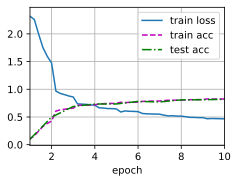

In [109]:
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

# 现代卷积神经网络

## AlexNet

In [112]:
import torch
from torch import nn
from d2l import torch as d2l
net = nn.Sequential(
    # 这里使用一个11*11的更大窗口来捕捉对象。
    # 同时，步幅为4，以减少输出的高度和宽度。
    # 另外，输出通道的数目远大于LeNet
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 减小卷积窗口，使用填充为2来使得输入与输出的高和宽一致，且增大输出通道数
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 使用三个连续的卷积层和较小的卷积窗口。
    # 除了最后的卷积层，输出通道的数量进一步增加。
    # 在前两个卷积层之后，汇聚层不用于减少输入的高度和宽度
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    # 这里，全连接层的输出数量是LeNet中的好几倍。使用dropout层来减轻过拟合
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    # 最后是输出层。由于这里使用Fashion-MNIST，所以用类别数为10，而非论文中的1000
    nn.Linear(4096, 10))

In [113]:
batch_size = 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)

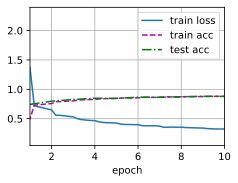

In [114]:
lr, num_epochs = 0.01, 10
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## VGG

In [2]:

def vgg_block(num_convs, in_channels, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels, out_channels,kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        in_channels = out_channels
    layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
    return nn.Sequential(*layers)

In [1]:
conv_arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))

In [103]:
def vgg(conv_arch):
    conv_blks=[]
    in_channels=1
    for (num_convs,out_channels) in conv_arch:
        conv_blks.append(vgg_block(num_convs, in_channels, out_channels))
        in_channels=out_channels
    return nn.Sequential(*conv_blks,nn.Flatten(),
                         nn.Linear(out_channels * 7 * 7, 4096), nn.ReLU(),
                         nn.Dropout(0.5),nn.Linear(4096, 4096), nn.ReLU(),
                         nn.Dropout(0.5),nn.Linear(4096, 10))
net = vgg(conv_arch)

In [104]:
X = torch.randn(size=(1, 1, 224, 224))
for blk in net:
    X = blk(X)
    print(blk.__class__.__name__,'output shape:\t',X.shape)

Sequential output shape:	 torch.Size([1, 64, 112, 112])
Sequential output shape:	 torch.Size([1, 128, 56, 56])
Sequential output shape:	 torch.Size([1, 256, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


In [5]:
net= vgg(conv_arch)

In [110]:
ratio = 4
small_conv_arch = [(pair[0], pair[1] // ratio) for pair in conv_arch]
net = vgg(small_conv_arch)

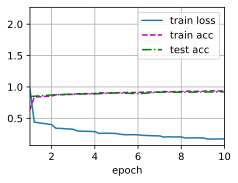

In [109]:
lr, num_epochs, batch_size = 0.05, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size,resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## NIN

In [111]:
import torch
from torch import nn
from d2l import torch as d2l
def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
    nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),nn.ReLU(),
    nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
    nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU())

In [112]:
net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten())

## GoogleNet

In [114]:
class Inception(nn.Module):
# c1--c4是每条路径的输出通道数
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # 线路1，单1x1卷积层
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        # 线路2，1x1卷积层后接3x3卷积层
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)# 线路3，1x1卷积层后接5x5卷积层
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)# 线路4，3x3最大汇聚层后接1x1卷积层
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)
    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        # 在通道维度上连结输出
        return torch.cat((p1, p2, p3, p4), dim=1)

In [115]:
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [116]:
b2 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=1),
                    nn.ReLU(),
                    nn.Conv2d(64, 192, kernel_size=3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [117]:
b3 = nn.Sequential(Inception(192, 64, (96, 128), (16, 32), 32),
                    Inception(256, 128, (128, 192), (32, 96), 64),
                    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [118]:
b4 = nn.Sequential(Inception(480, 192, (96, 208), (16, 48), 64),
Inception(512, 160, (112, 224), (24, 64), 64),
Inception(512, 128, (128, 256), (24, 64), 64),
Inception(512, 112, (144, 288), (32, 64), 64),
Inception(528, 256, (160, 320), (32, 128), 128),nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [119]:
b5 = nn.Sequential(Inception(832, 256, (160, 320), (32, 128), 128),Inception(832, 384, (192, 384), (48, 128), 128),nn.AdaptiveAvgPool2d((1,1)),
nn.Flatten())
net = nn.Sequential(b1, b2, b3, b4, b5, nn.Linear(1024, 10))

In [120]:
import torch
from torch import nn
from d2l import torch as d2l
def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):# 通过is_grad_enabled来判断当前模式是训练模式还是预测模式
    if not torch.is_grad_enabled():
        # 如果是在预测模式下，直接使用传入的移动平均所得的均值和方差
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # 使用全连接层的情况，计算特征维上的均值和方差
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # 使用二维卷积层的情况，计算通道维上（axis=1）的均值和方差。# 这里我们需要保持X的形状以便后面可以做广播运算
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # 训练模式下，用当前的均值和方差做标准化
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # 更新移动平均的均值和方差
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    Y = gamma * X_hat + beta # 缩放和移位
    return Y, moving_mean.data, moving_var.data

In [ ]:
class BatchNorm(nn.Module):
    # num_features：完全连接层的输出数量或卷积层的输出通道数。# num_dims：2表示完全连接层，4表示卷积层
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # 参与求梯度和迭代的拉伸和偏移参数，分别初始化成1和0
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # 非模型参数的变量初始化为0和1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)
        def forward(self, X):
            # 如果X不在内存上，将moving_mean和moving_var
            # 复制到X所在显存上
            if self.moving_mean.device != X.device:
                self.moving_mean = self.moving_mean.to(X.device)
                self.moving_var = self.moving_var.to(X.device)
            # 保存更新过的moving_mean和moving_var
            Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.9)
            return Y

In [122]:
def conv_block(input_channels, num_channels):
    return nn.Sequential(
    nn.BatchNorm2d(input_channels), nn.ReLU(),
    nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1))

In [124]:
class DenseBlock(nn.Module):
    def __init__(self, num_convs, input_channels, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(num_channels * i + input_channels, num_channels))
        self.net = nn.Sequential(*layer)
    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
        # 连接通道维度上每个块的输入和输出
            X = torch.cat((X, Y), dim=1)
        return X

In [125]:
def transition_block(input_channels, num_channels):
    return nn.Sequential(
    nn.BatchNorm2d(input_channels), nn.ReLU(),
    nn.Conv2d(input_channels, num_channels, kernel_size=1),nn.AvgPool2d(kernel_size=2, stride=2))

In [126]:
b1 = nn.Sequential(
nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),nn.BatchNorm2d(64), nn.ReLU(),
nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [127]:
# num_channels为当前的通道数
num_channels, growth_rate = 64, 32
num_convs_in_dense_blocks = [4, 4, 4, 4]
blks = []
for i, num_convs in enumerate(num_convs_in_dense_blocks):
    blks.append(DenseBlock(num_convs, num_channels, growth_rate))
    # 上一个稠密块的输出通道数
    num_channels += num_convs * growth_rate
    # 在稠密块之间添加一个转换层，使通道数量减半
    if i != len(num_convs_in_dense_blocks) - 1:
        blks.append(transition_block(num_channels, num_channels // 2))
        num_channels = num_channels // 2

In [128]:
net = nn.Sequential(
b1, *blks,
nn.BatchNorm2d(num_channels), nn.ReLU(),nn.AdaptiveAvgPool2d((1, 1)),
nn.Flatten(),
nn.Linear(num_channels, 10))